## Flux optique
Le flux optique représente comment les pixels d'une image se déplacent d'une frame à une autre. Le but de ce TP est d'étudier le déplacement de ces pixels sur des images extraites d'une séquence vidéo en utilisant la méthode Lucas-Kanade. (Ne vous inquiètez pas, on va y aller étape par étape).


Soit les 2 images suivantes notées 'chat1.jpg' et 'chat2.jpg'.
1. Lire et afficher les 2 images en niveau de gris.

In [18]:
#Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
import random

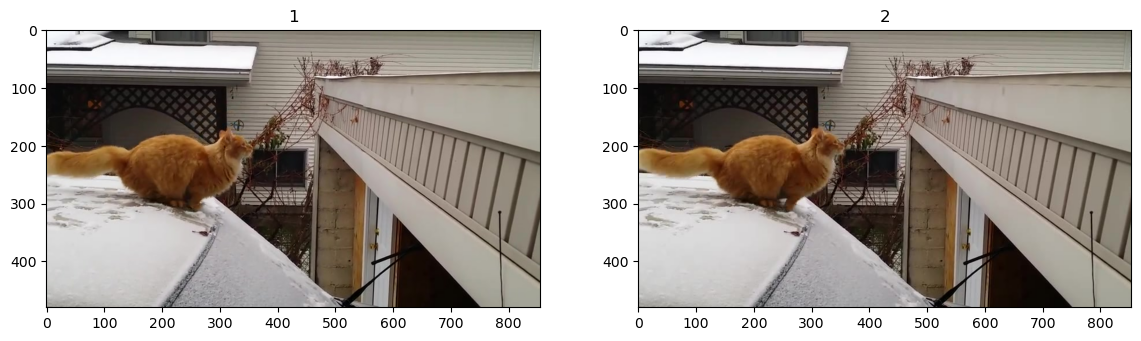

In [19]:
## Code here
str(3/4)*2

path_base = 'Base_images/'
img1 = cv2.imread(path_base+'chat1.jpg',-1) 
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(path_base+'chat2.jpg',-1) 
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.subplot(1,2,1)
plt.imshow(img1)
# plt.axis(False)
plt.title("1")
plt.subplot(1,2,2)
plt.imshow(img2)
# plt.axis(False)
plt.title("2")
plt.show()


2. A l'aide de la fonction OpenCV 'goodFeaturesToTrack', stockez les contours de l'image 1 que vous allez utiliser par la suite. Affichez le résultat sur l'image 1

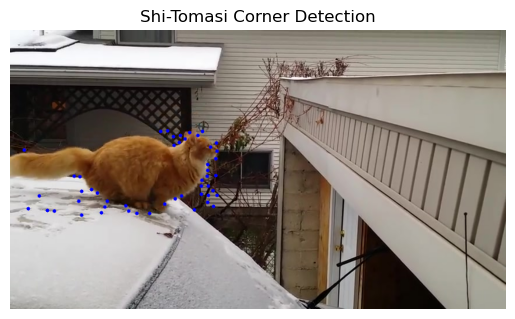

In [20]:
# Code here
gray_img = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

mask = np.zeros_like(gray_img)
mask[170:320, 0:360] = 255   # ROI containing your object

corners = cv2.goodFeaturesToTrack(gray_img, 50, 0.01, 10, mask=mask)
corners = corners.astype(int)

# corners = cv2.goodFeaturesToTrack(gray_img, 5, 0.01, 10)
# corners = np.int32(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(img1, (x, y), 3, (0, 0, 255), -1)  


plt.imshow(img1)
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')  
plt.show()

3. Écrire un programme (une fonction) qui calcule les dérivées partielles Ix, Iy, It qui aura en entrée 2 images consécutives et envoie en sortie les 3 dérivées partielles (vous pouvez utiliser la fonction signal.convolve2d si vous voulez)

\begin{equation*}
    I_x = I * M_x
\end{equation*}

\begin{equation*}
    I_y = I * M_y
\end{equation*}

\begin{equation*}
M_{x} = \begin{bmatrix} -1 & 1 \\ -1 & 1 \end{bmatrix}
\end{equation*}

\begin{equation*}
M_{y} = \begin{bmatrix} -1 & -1 \\ 1 & 1 \end{bmatrix}
\end{equation*}


In [21]:
# Code here
def compute_derivatives(img1, img2):
    img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    # masques
    Mx = np.array([[-1, 1],
                   [-1, 1]], dtype=np.float32)

    My = np.array([[-1, -1],
                   [ 1,  1]], dtype=np.float32)

    # dérivées spatiales 
    Ix = signal.convolve2d(img1, Mx, boundary='symm', mode='same')
    Iy = signal.convolve2d(img1, My, boundary='symm', mode='same')

    # Dérivée temporelle
    It = img2 - img1

    return Ix, Iy, It

4. Appliquer cette fonction à deux des images consécutives qui vous sont proposées et afficher $I_t$

In [22]:
# Code here
Ix, Iy, It = compute_derivatives(img1, img2)


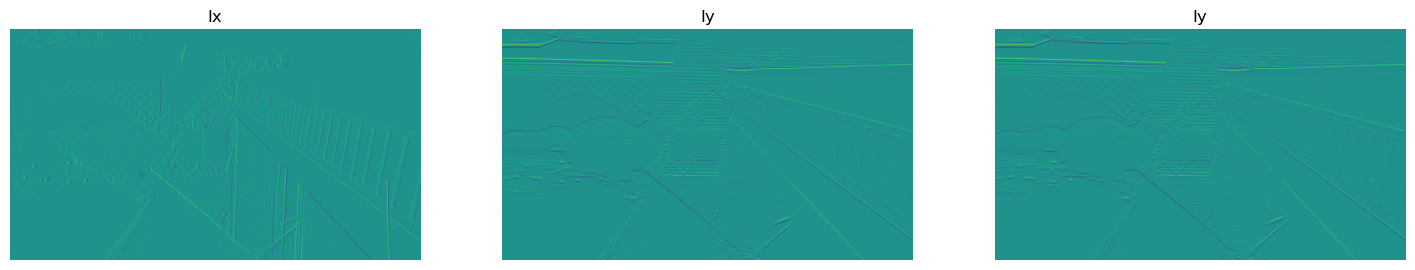

In [23]:
plt.figure(figsize=(18, 10))
plt.subplot(1,3,1)
plt.imshow(Ix)
plt.axis(False)
plt.title("Ix")
plt.subplot(1,3,2)
plt.imshow(Iy)
plt.axis(False)
plt.title("Iy")
plt.subplot(1,3,3)
plt.imshow(Iy)
plt.axis(False)
plt.title("Iy")
plt.show()

5. Écrire une fonction Lucas_kanade(Ix, Iy, It, features) qui a en entrée les coordonnées des points d’intérêts détectés et qui envoie en sortie le vecteur du mouvement (u,v) entre chaque paire d’images consécutives


Rappel :

\begin{equation*}
    A = [I_x, I_y]
\end{equation*}

\begin{equation*}
    b = -I_t
\end{equation*}

\begin{equation*}
    [u,v] = (A^T.A)^{-1}.A^T.b
\end{equation*}

Il faut calculer
\begin{equation*}
    I_x, I_y et I_t 
\end{equation*}
 pour les pixels voisinants

In [24]:
# Code here
import numpy as np

def Lucas_kanade(Ix, Iy, It, features, window_size=5):
    """
    Ix, Iy, It : dérivées partielles (images)
    features : points d’intérêt (format goodFeaturesToTrack)
    window_size : taille de la fenêtre locale (impair recommandé)
    
    Retour :
    motions : liste des vecteurs (u, v) pour chaque point
    """

    half_w = window_size // 2
    motions = []

    for pt in features:
        x, y = pt.ravel()

        # Vérifier que la fenêtre reste dans l’image
        if (x - half_w < 0 or x + half_w >= Ix.shape[1] or
            y - half_w < 0 or y + half_w >= Ix.shape[0]):
            motions.append((0, 0))
            continue

        # Extraire les voisinages
        Ix_win = Ix[y-half_w:y+half_w+1, x-half_w:x+half_w+1].flatten()
        Iy_win = Iy[y-half_w:y+half_w+1, x-half_w:x+half_w+1].flatten()
        It_win = It[y-half_w:y+half_w+1, x-half_w:x+half_w+1].flatten()

        # Construire A et b
        A = np.vstack((Ix_win, Iy_win)).T
        b = -It_win

        # Calculer (A^T A) et (A^T b)
        ATA = A.T @ A
        ATb = A.T @ b

        # Vérifier que la matrice est inversible
        if np.linalg.det(ATA) < 1e-6:
            motions.append((0, 0))
            continue

        # Résolution
        nu = np.linalg.inv(ATA) @ ATb
        u, v = nu

        motions.append((u, v))

    return np.array(motions)


6. Appliquer cette fonction sur les images proposées (par paire). Superposer les vecteurs du déplacement (u,v) en rouge sur chaque image de départ. 

(N'hésitez pas à utiliser la fonction np.arrow pour afficher les vecteurs)

In [25]:
motions = Lucas_kanade(Ix, Iy, It, corners)

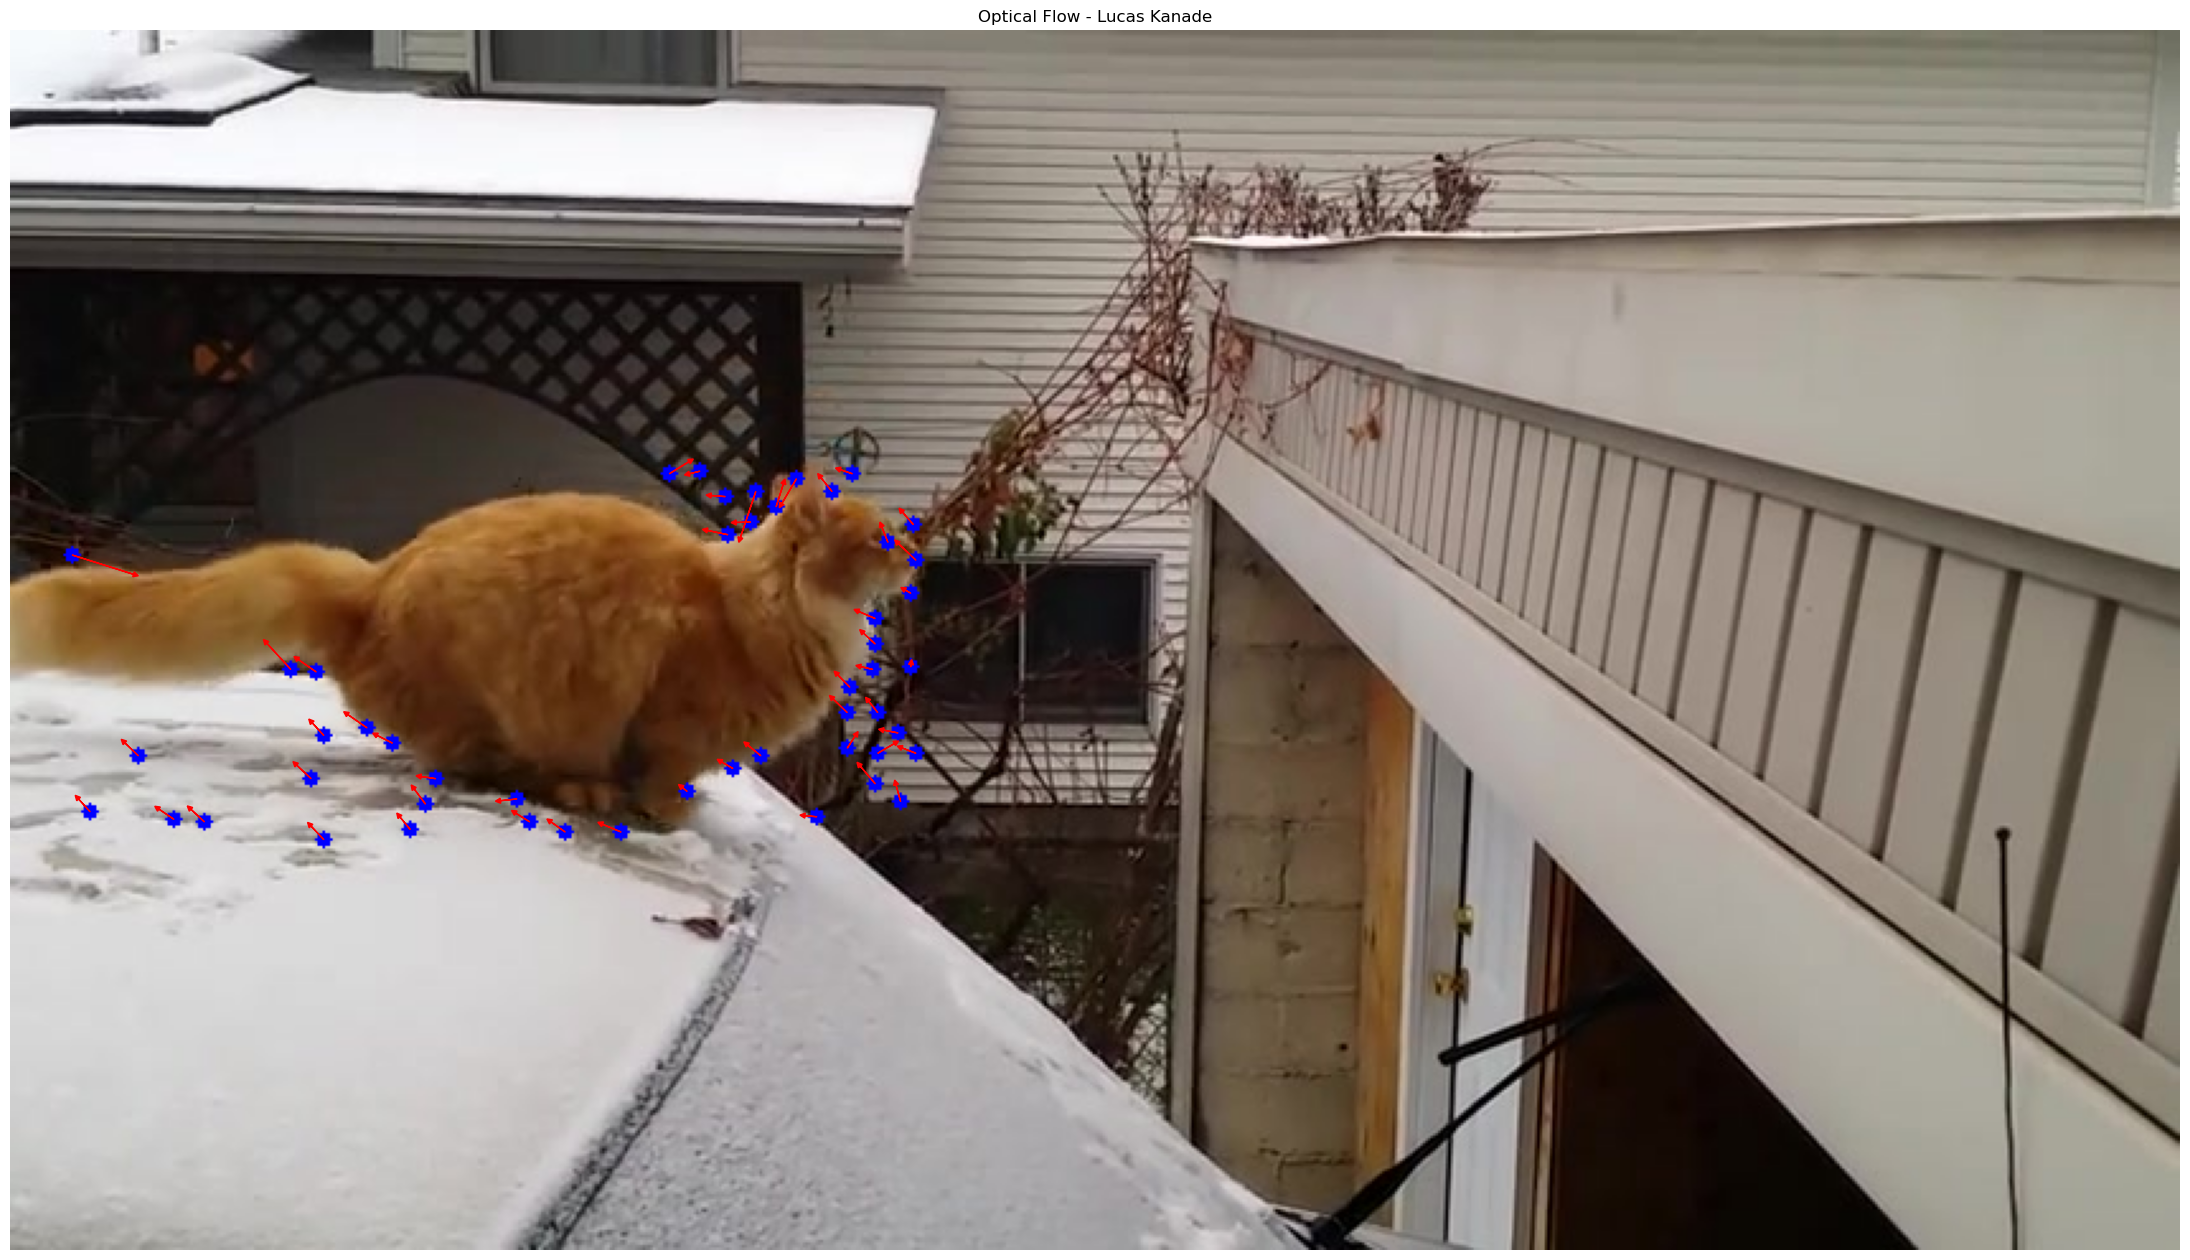

In [26]:
# Code here
plt.figure(figsize=(28, 20))
plt.imshow(img1)
plt.axis("off")

for (pt, motion) in zip(corners, motions):
    x, y = pt.ravel()
    u, v = motion

    plt.arrow(x, y, u*10, v*10,
              color='red',
              head_width=2,
              head_length=2)

plt.title("Optical Flow - Lucas Kanade")
plt.show()


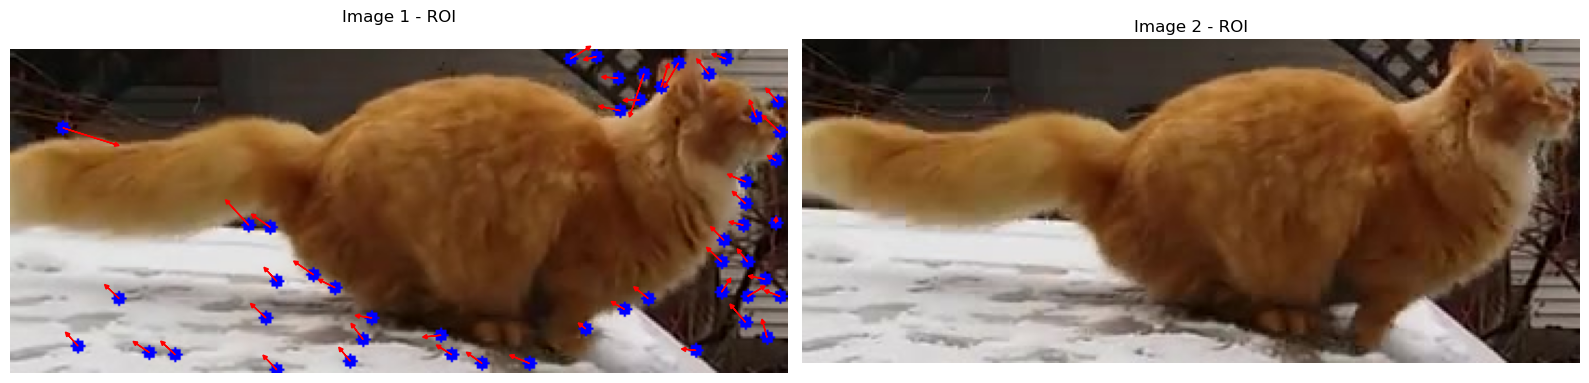

In [27]:
# Define ROI
y1, y2 = 170, 320
x1, x2 = 0, 360

# Crop images
img1_crop = img1[y1:y2, x1:x2]
img2_crop = img2[y1:y2, x1:x2]

plt.figure(figsize=(16, 8))

# --- First Image ---
plt.subplot(1, 2, 1)
plt.imshow(img1_crop)
plt.axis("off")
plt.title("Image 1 - ROI")

for (pt, motion) in zip(corners, motions):
    x, y = pt.ravel()
    
    # Only draw points inside ROI
    if x1 <= x < x2 and y1 <= y < y2:
        u, v = motion
        
        # Shift coordinates to cropped reference
        x_shifted = x - x1
        y_shifted = y - y1
        
        plt.arrow(x_shifted, y_shifted,
                  u*10, v*10,
                  color='red',
                  head_width=2,
                  head_length=2)

# --- Second Image ---
plt.subplot(1, 2, 2)
plt.imshow(img2_crop)
plt.axis("off")
plt.title("Image 2 - ROI")

plt.tight_layout()
plt.show()


9. Les résultats sont-ils conformes à la théorie vue en cours ? Analysez et expliquez :)

10. Appliquer votre code sur les deux images frame7 et frame14. Qu'en concluez vous (visuellement) quant à l'efficacité de la méthode de Lucas et Kanade?


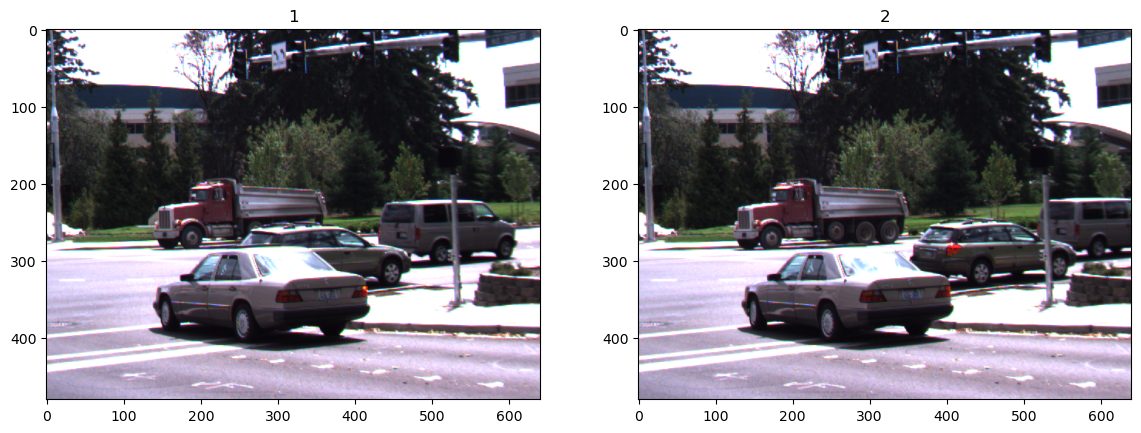

In [28]:
img1 = cv2.imread(path_base+'frame07.png',-1) 
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(path_base+'frame14.png',-1) 
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.subplot(1,2,1)
plt.imshow(img1)
# plt.axis(False)
plt.title("1")
plt.subplot(1,2,2)
plt.imshow(img2)
# plt.axis(False)
plt.title("2")
plt.show()

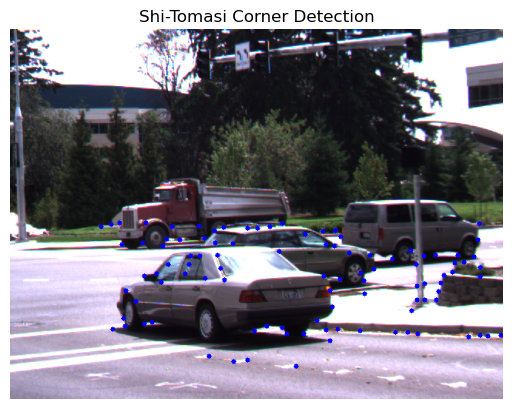

In [29]:
# Code here
gray_img = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

mask = np.zeros_like(gray_img)
mask[250:450, 100:] = 255   # ROI containing your object

corners = cv2.goodFeaturesToTrack(gray_img, 100, 0.01, 10, mask=mask)
corners = corners.astype(int)

# corners = cv2.goodFeaturesToTrack(gray_img, 5, 0.01, 10)
# corners = np.int32(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(img1, (x, y), 3, (0, 0, 255), -1)  


plt.imshow(img1)
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')  
plt.show()

In [30]:
# gray_img = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# corners = cv2.goodFeaturesToTrack(gray_img, 100, 0.01, 10)
# corners = np.int32(corners)

# for i in corners:
#     x, y = i.ravel()
#     cv2.circle(img1, (x, y), 3, (0, 0, 255), -1)  


# plt.imshow(img1)
# plt.title('Shi-Tomasi Corner Detection')
# plt.axis('off')  
# plt.show()

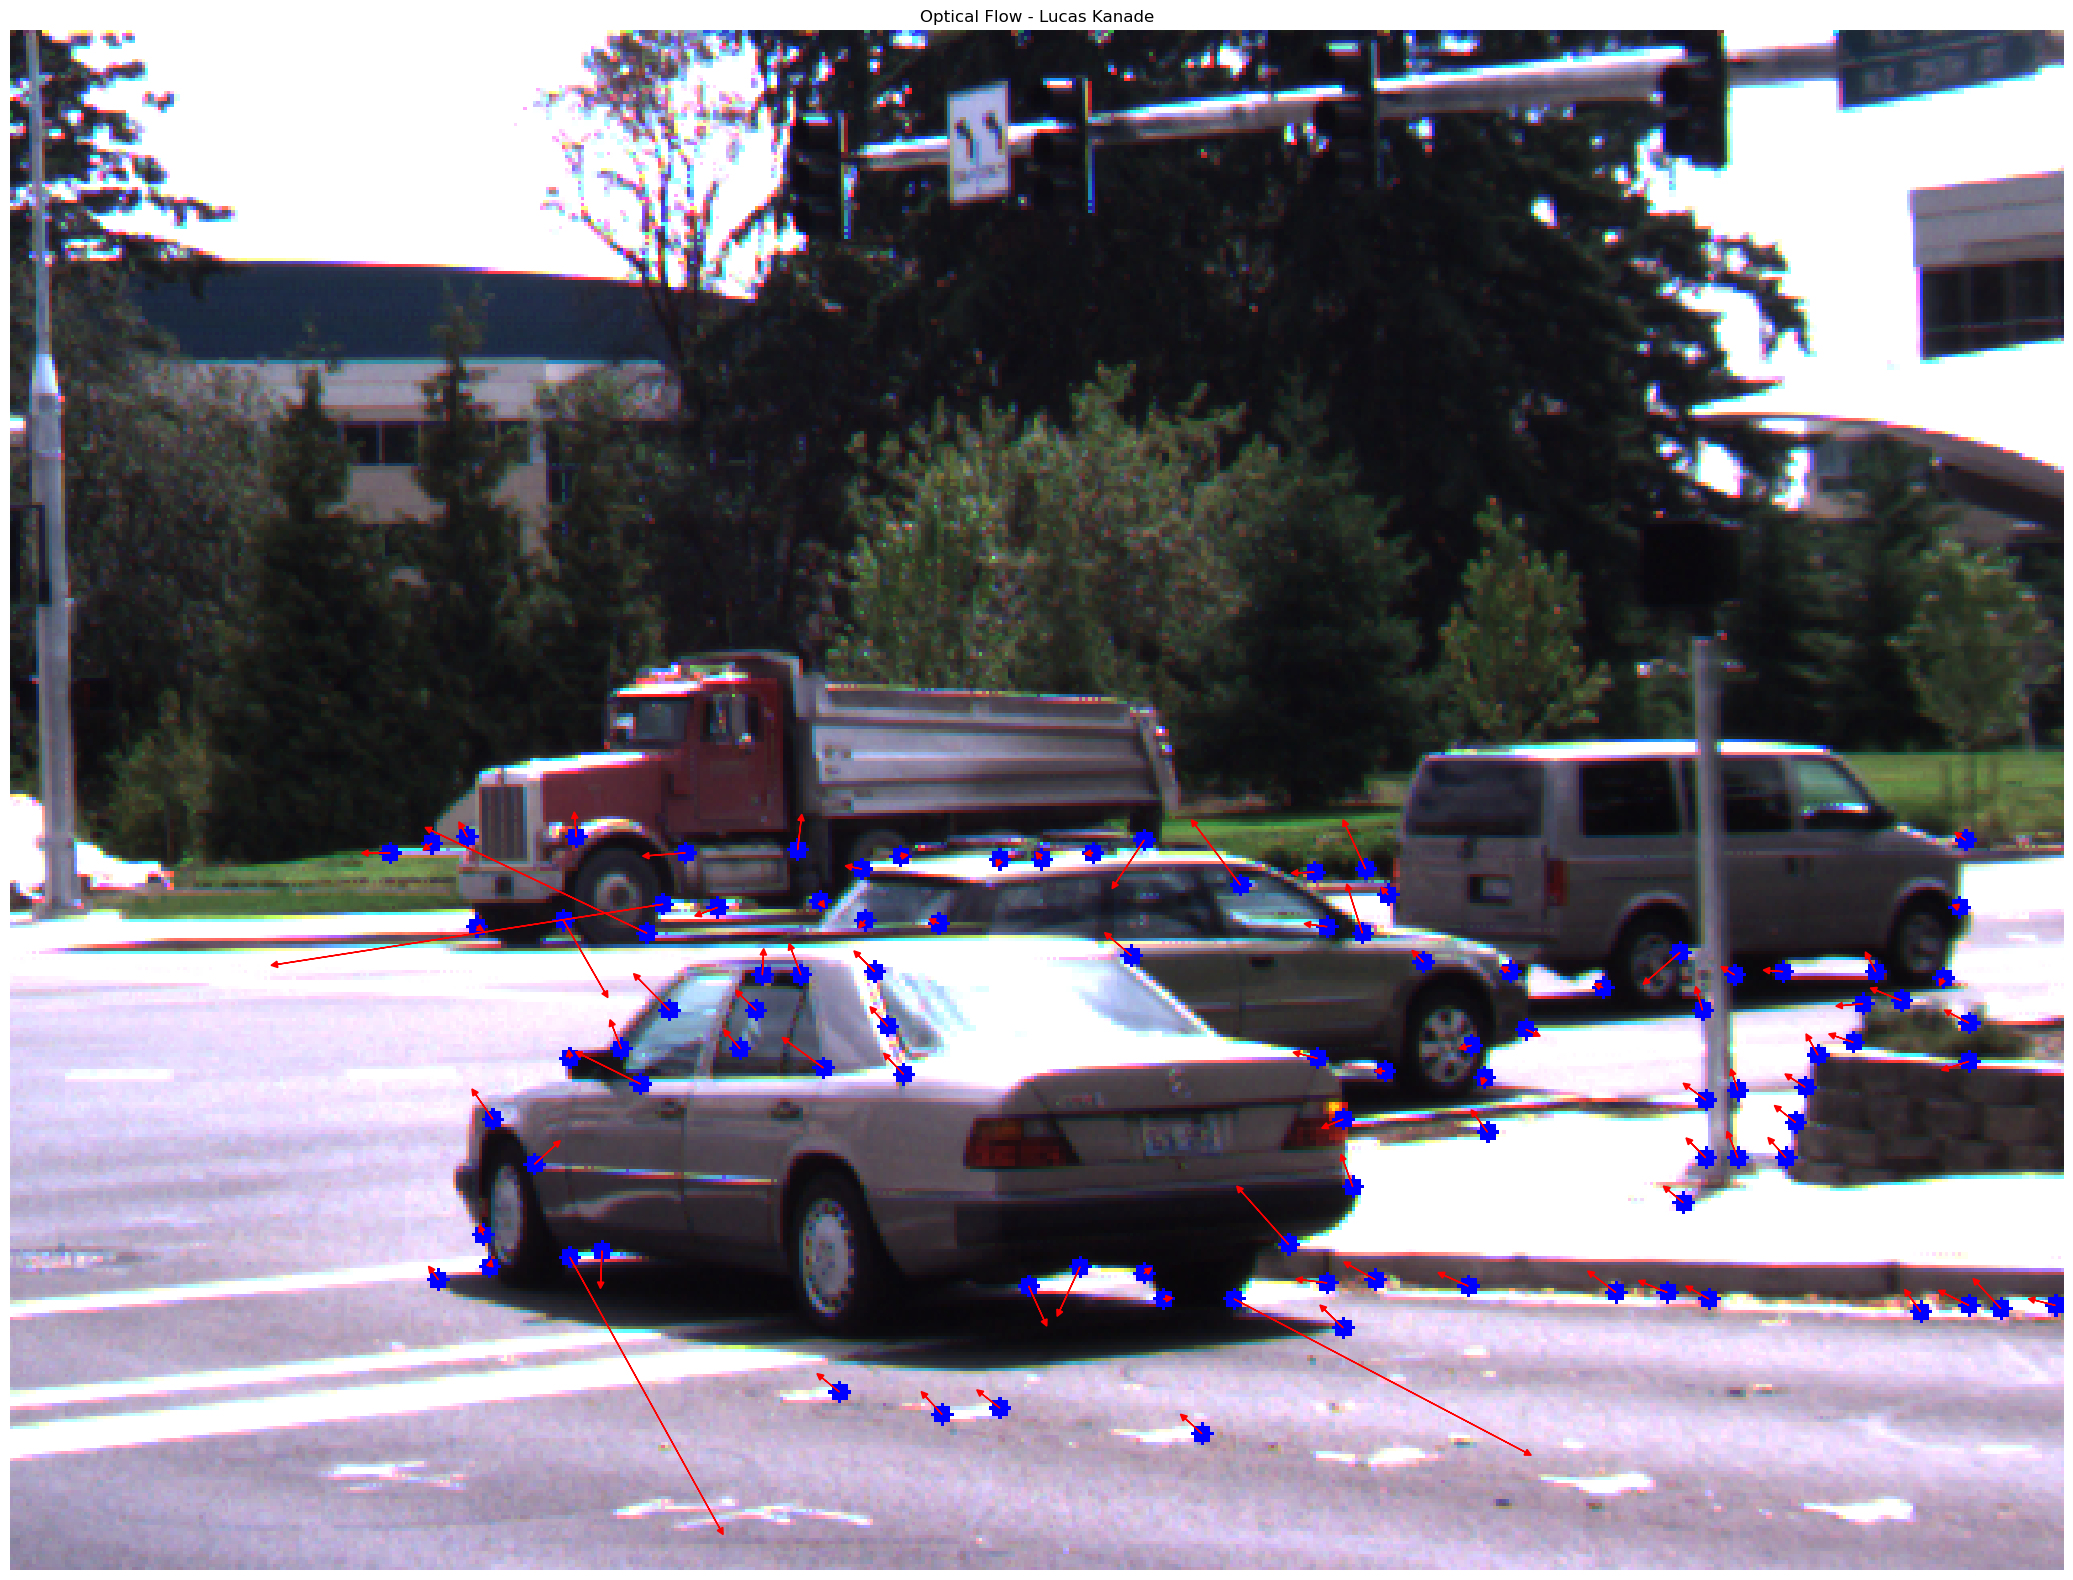

In [31]:
Ix, Iy, It = compute_derivatives(img1, img2)

motions = Lucas_kanade(Ix, Iy, It, corners)

plt.figure(figsize=(28, 20))
plt.imshow(img1)
plt.axis("off")

for (pt, motion) in zip(corners, motions):
    x, y = pt.ravel()
    u, v = motion

    plt.arrow(x, y, u*10, v*10,
              color='red',
              head_width=2,
              head_length=2)

plt.title("Optical Flow - Lucas Kanade")
plt.show()
